In [8]:
import numpy as np 
import pandas as pandas
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [9]:
#load_data 
df = pd.read_parquet('../data/Divar_cleaned.parquet')

In [10]:
import pandas as pd

text_corpus = (
    (df['title'].fillna('') + ' ' + df['description'].fillna(''))
    .str.replace('ي', 'ی')
    .str.replace('ك', 'ک')
    .str.lower()
)

# regex pattern
balcony_pattern = 'بالکن|تراس|بهارخواب|پاسیو'
elevator_pattern = 'آسانسور|اسانسور|الواتور'
guard_pattern = 'نگهبان|لابی‌من|لابی من|سرایدار|حراست'
bbq_pattern = 'باربیکیو|باربکیو|باربیکو|کباب‌پز|کباب پز'
pool_pattern = 'استخر'

df_clean = df[['city_slug', 'neighborhood_slug']].copy()

df_clean['has_balcony_clean'] = (
    df['has_balcony'] == True
) | text_corpus.str.contains(balcony_pattern, regex=True)
df_clean['has_elevator_clean'] = (
    df['has_elevator'] == True
) | text_corpus.str.contains(elevator_pattern, regex=True)
df_clean['has_security_guard_clean'] = (
    df['has_security_guard'] == True
) | text_corpus.str.contains(guard_pattern, regex=True)
df_clean['has_barbecue_clean'] = (
    df['has_barbecue'] == True
) | text_corpus.str.contains(bbq_pattern, regex=True)
df_clean['has_pool_clean'] = (
    df['has_pool'] == True
) | text_corpus.str.contains(pool_pattern, regex=True)


all_amenities_condition = (
    df_clean['has_balcony_clean']
    & df_clean['has_elevator_clean']
    & df_clean['has_security_guard_clean']
    & df_clean['has_barbecue_clean']
    & df_clean['has_pool_clean']
)

luxury_homes_clean = df_clean[all_amenities_condition]
print(f'تعداد املاک واقعی پیدا شده: {len(luxury_homes_clean)}')

تعداد املاک واقعی پیدا شده: 188


<div dir="rtl">

### پاک‌سازی داده‌ها و استخراج امکانات رفاهی از متن (Text Mining & Feature Cleaning)

به دلیل **وجود داده‌های مفقود (Missing Values / NaN)** و عدم ثبت کامل تیک‌های مربوط به امکانات رفاهی توسط کاربران در ستون‌های ساخت‌یافته، تنها اتکا به ستون‌های بولین باعث از دست رفتن بخش زیادی از اطلاعات واقعی می‌شد. 

در این سلول، فرآیند **آماده سازی ویژگی‌ها (Feature Engineering)** و **پاک‌سازی داده‌ها** طی مراحل زیر انجام می‌گیرد:

1. **نرمال‌سازی و یکسان‌سازی متنی:**
   * ترکیب دو ستون عنوان (`title`) و توضیحات (`description`) متن کامل تر.
   * اصلاح و یکسان‌سازی کاراکترهای عربی («ي» و «ك») به فارسی («ی» و «ک»).

2. **تعریف الگوهای جامع نگارشی (Regex Patterns):**
   * تعریف طیف وسیعی از مترادف‌ها، واژگان هم‌معنی و اشتباهات رایج املایی برای هر ۵ امکانات رفاهی (بالکن، آسانسور، نگهبان، باربیکیو و استخر).

3. **ترکیب ستون‌های ساخت‌یافته با متون غیرساختاریافته:**
   * ایجاد ستون‌های پاک‌سازی‌شده جدید (`clean_...`) به طوری که اگر ویژگی در ستون اصلی ثبت نشده باشد، اما در متن آگهی به آن اشاره شده باشد، مقدار آن به `True` تغییر یابد.

4. **فیلتر نهایی:**
   * استخراج دقیق املاکی که هم‌زمان دارای هر **۵ امکانات رفاهی** هستند.

   </div>

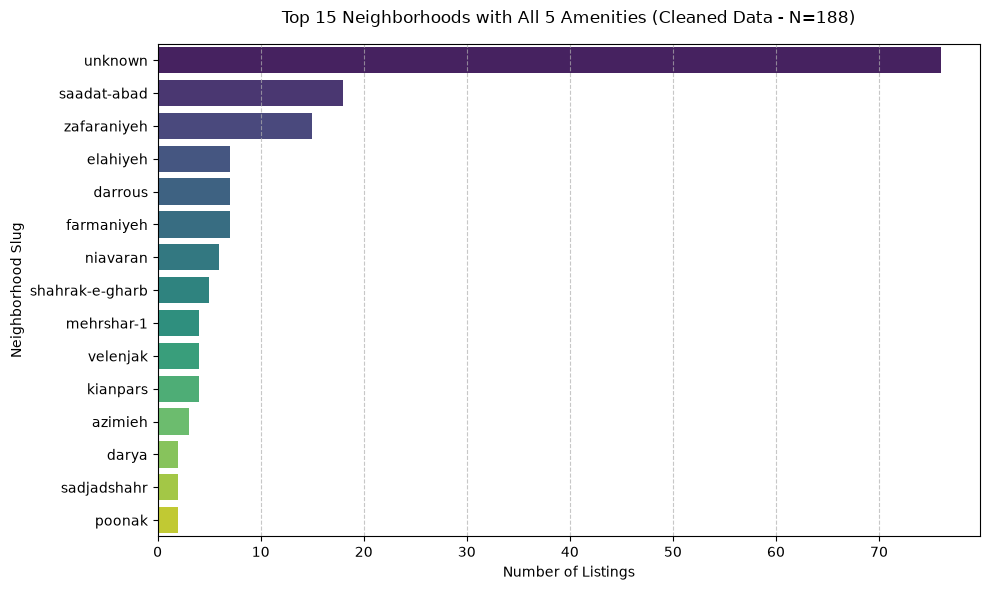

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

top_neighborhoods = (
    luxury_homes_clean['neighborhood_slug'].value_counts().head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_neighborhoods.values,
    y=top_neighborhoods.index,
    hue=top_neighborhoods.index,
    legend=False,
    palette='viridis',
)

plt.title(
    'Top 15 Neighborhoods with All 5 Amenities (Cleaned Data - N=188)',
    fontsize=12,
    pad=15,
)
plt.xlabel('Number of Listings', fontsize=10)
plt.ylabel('Neighborhood Slug', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<div dir="rtl">

### تحلیل پراکندگی ۱۵ محله برتر دارای تمام ۵ امکانات رفاهی

در این بخش، پراکندگی جغرافیایی املاکی که دارای **هر ۵ امکانات رفاهی اصلی** (بالکن، آسانسور، نگهبان/لابی‌من، باربیکیو و استخر) هستند را بررسی می‌کنیم.

 پس از پیش‌پردازش متن آگهی‌ها و پرسازی مقادیر مفقود، در مجموع **۱۸۸ ملک** با تمام این ویژگی‌ها شناسایی شدند ($N=188$).

کد بالا ۱۵ محله‌ای که بیشترین سهم را از این املاک دارند به‌صورت نمودار میله‌ای افقی نمایش می‌دهد:

   </div>